# NBAIoT Dataset — ML Classification Analysis

**Dataset:** [N-BaIoT on Kaggle](https://www.kaggle.com/datasets/mkashifn/nbaiot-dataset)  
**Task 1:** Binary classification — benign vs malicious traffic  
**Task 2:** Multiclass classification — determine attack type  
**Algorithms:** Decision Tree · Random Forest · XGBoost (CPU only)  
**Metrics:** Accuracy · Precision · Recall


## 0. Hardware & Environment Info

In [2]:
import platform
import os
import psutil
import subprocess

print("=" * 60)
print("SYSTEM CONFIGURATION")
print("=" * 60)

# OS
print(f"OS               : {platform.system()} {platform.release()} ({platform.version()})")
print(f"Machine          : {platform.machine()}")
print(f"Processor        : {platform.processor()}")
print(f"Python           : {platform.python_version()}")

# CPU
print(f"CPU Physical cores: {psutil.cpu_count(logical=False)}")
print(f"CPU Logical cores : {psutil.cpu_count(logical=True)}")
try:
    cpu_freq = psutil.cpu_freq()
    print(f"CPU Max freq      : {cpu_freq.max:.0f} MHz")
except Exception:
    pass

# RAM
ram = psutil.virtual_memory()
print(f"RAM Total         : {ram.total / (1024**3):.2f} GB")
print(f"RAM Available     : {ram.available / (1024**3):.2f} GB")

# GPU (optional — nvidia-smi)
print()
try:
    gpu_info = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
         "--format=csv,noheader"],
        stderr=subprocess.DEVNULL
    ).decode().strip()
    print(f"GPU              : {gpu_info}")
    print("NOTE: XGBoost will run on CPU (tree_method='hist', device='cpu')")
except Exception:
    print("GPU              : Not detected (or nvidia-smi not available)")
    print("NOTE: XGBoost will run on CPU")

# Library versions
print()
print("=" * 60)
print("LIBRARY VERSIONS")
print("=" * 60)
import sklearn, xgboost, numpy, pandas
print(f"scikit-learn     : {sklearn.__version__}")
print(f"xgboost          : {xgboost.__version__}")
print(f"numpy            : {numpy.__version__}")
print(f"pandas           : {pandas.__version__}")

SYSTEM CONFIGURATION
OS               : Linux 5.4.0-216-generic (#236-Ubuntu SMP Fri Apr 11 19:53:21 UTC 2025)
Machine          : x86_64
Processor        : x86_64
Python           : 3.10.12
CPU Physical cores: 16
CPU Logical cores : 32
CPU Max freq      : 0 MHz
RAM Total         : 251.89 GB
RAM Available     : 248.73 GB

GPU              : Not detected (or nvidia-smi not available)
NOTE: XGBoost will run on CPU

LIBRARY VERSIONS
scikit-learn     : 1.2.2
xgboost          : 1.7.6
numpy            : 1.22.4
pandas           : 1.5.3


## 1. Imports

In [3]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK")

Imports OK


## 2. Load Dataset

> **Download** the dataset from Kaggle and place all CSV files in the same folder as this notebook  
> (or change `DATA_DIR` below to the path where you extracted the archive).
>
> Expected files (at minimum):  
> `1.benign.csv`, `2.mirai_attacks/`, `3.gafgyt_attacks/`  
> The cell below auto-discovers all CSVs and assigns labels automatically.

In [5]:
# ── Change this to your dataset directory ──────────────────────────────────
DATA_DIR = Path("../datasets")   # default: same folder as this notebook
# ───────────────────────────────────────────────────────────────────────────

# Map each CSV file name → attack-type label
# Files are named like: 1.benign.csv, mirai.scan.csv, gafgyt.combo.csv, etc.
BENIGN_KEYWORDS   = ["benign"]

csv_files = sorted(DATA_DIR.rglob("*.csv"))
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(f"  {f}")

assert len(csv_files) > 0, (
    "No CSV files found! "
    "Please set DATA_DIR to the folder containing the N-BaIoT CSVs."
)

Found 89 CSV file(s):
  ../datasets/1.benign.csv
  ../datasets/1.gafgyt.combo.csv
  ../datasets/1.gafgyt.junk.csv
  ../datasets/1.gafgyt.scan.csv
  ../datasets/1.gafgyt.tcp.csv
  ../datasets/1.gafgyt.udp.csv
  ../datasets/1.mirai.ack.csv
  ../datasets/1.mirai.scan.csv
  ../datasets/1.mirai.syn.csv
  ../datasets/1.mirai.udp.csv
  ../datasets/1.mirai.udpplain.csv
  ../datasets/2.benign.csv
  ../datasets/2.gafgyt.combo.csv
  ../datasets/2.gafgyt.junk.csv
  ../datasets/2.gafgyt.scan.csv
  ../datasets/2.gafgyt.tcp.csv
  ../datasets/2.gafgyt.udp.csv
  ../datasets/2.mirai.ack.csv
  ../datasets/2.mirai.scan.csv
  ../datasets/2.mirai.syn.csv
  ../datasets/2.mirai.udp.csv
  ../datasets/2.mirai.udpplain.csv
  ../datasets/3.benign.csv
  ../datasets/3.gafgyt.combo.csv
  ../datasets/3.gafgyt.junk.csv
  ../datasets/3.gafgyt.scan.csv
  ../datasets/3.gafgyt.tcp.csv
  ../datasets/3.gafgyt.udp.csv
  ../datasets/4.benign.csv
  ../datasets/4.gafgyt.combo.csv
  ../datasets/4.gafgyt.junk.csv
  ../datasets/4.

In [6]:
frames = []

for fpath in csv_files:
    df_tmp = pd.read_csv(fpath)

    # Derive multiclass label from file name
    stem = fpath.stem.lower()          # e.g. "1.benign", "mirai.scan"
    parent = fpath.parent.name.lower() # parent folder name

    is_benign = any(kw in stem or kw in parent for kw in BENIGN_KEYWORDS)

    if is_benign:
        label_multiclass = "benign"
    else:
        # Use the file stem (strip leading digits & dots) as attack type
        clean = stem.lstrip("0123456789.").strip().replace(" ", "_")
        label_multiclass = clean if clean else parent

    df_tmp["label_multi"]  = label_multiclass
    df_tmp["label_binary"] = 0 if is_benign else 1  # 0=benign, 1=malicious

    frames.append(df_tmp)
    print(f"  Loaded {len(df_tmp):>7,} rows  →  label='{label_multiclass}'  from {fpath.name}")

df = pd.concat(frames, ignore_index=True)
print(f"\nTotal shape: {df.shape}")

  Loaded  49,548 rows  →  label='benign'  from 1.benign.csv
  Loaded  59,718 rows  →  label='gafgyt.combo'  from 1.gafgyt.combo.csv
  Loaded  29,068 rows  →  label='gafgyt.junk'  from 1.gafgyt.junk.csv
  Loaded  29,849 rows  →  label='gafgyt.scan'  from 1.gafgyt.scan.csv
  Loaded  92,141 rows  →  label='gafgyt.tcp'  from 1.gafgyt.tcp.csv
  Loaded 105,874 rows  →  label='gafgyt.udp'  from 1.gafgyt.udp.csv
  Loaded 102,195 rows  →  label='mirai.ack'  from 1.mirai.ack.csv
  Loaded 107,685 rows  →  label='mirai.scan'  from 1.mirai.scan.csv
  Loaded 122,573 rows  →  label='mirai.syn'  from 1.mirai.syn.csv
  Loaded 237,665 rows  →  label='mirai.udp'  from 1.mirai.udp.csv
  Loaded  81,982 rows  →  label='mirai.udpplain'  from 1.mirai.udpplain.csv
  Loaded  13,113 rows  →  label='benign'  from 2.benign.csv
  Loaded  53,012 rows  →  label='gafgyt.combo'  from 2.gafgyt.combo.csv
  Loaded  30,312 rows  →  label='gafgyt.junk'  from 2.gafgyt.junk.csv
  Loaded  27,494 rows  →  label='gafgyt.scan'  f

## 3. Exploratory Data Analysis

In [7]:
print("── Binary label distribution ────────────────────────────")
bin_counts = df["label_binary"].value_counts().rename({0: "Benign", 1: "Malicious"})
print(bin_counts.to_string())
print()

print("── Multiclass label distribution ────────────────────────")
multi_counts = df["label_multi"].value_counts()
print(multi_counts.to_string())

── Binary label distribution ────────────────────────────
Malicious    6506674
Benign        555932

── Multiclass label distribution ────────────────────────
mirai.udp         1229999
gafgyt.udp         946366
gafgyt.tcp         859850
mirai.syn          733299
mirai.ack          643821
benign             555932
mirai.scan         537979
mirai.udpplain     523304
gafgyt.combo       515156
gafgyt.junk        261789
gafgyt.scan        255111


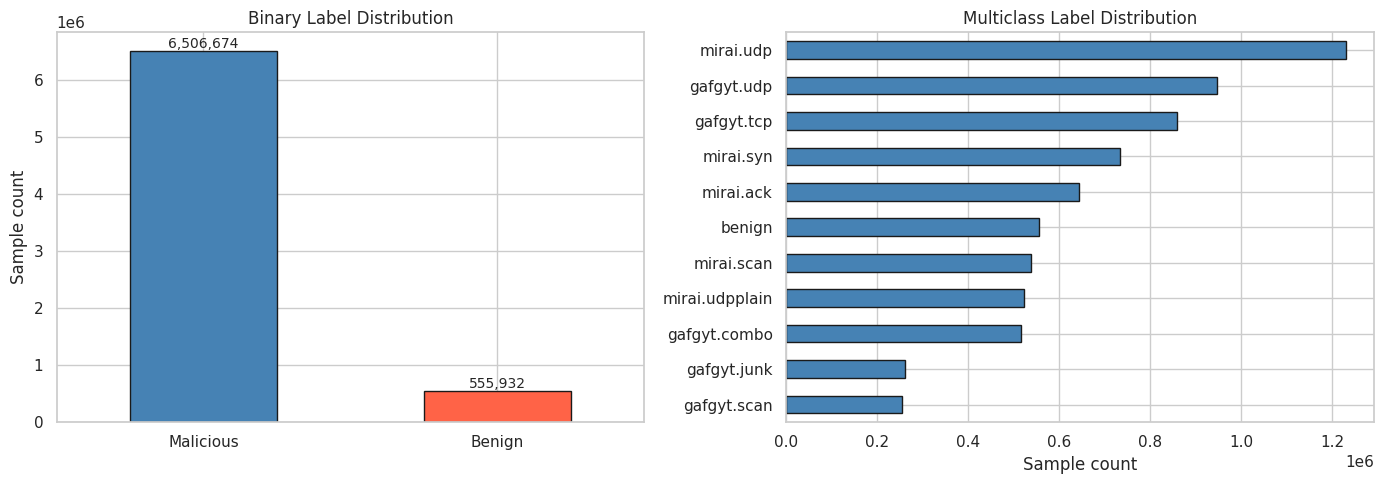

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
bin_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="k")
axes[0].set_title("Binary Label Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sample count")
axes[0].tick_params(axis="x", rotation=0)

for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Multiclass
multi_counts.plot(kind="barh", ax=axes[1], color="steelblue", edgecolor="k")
axes[1].set_title("Multiclass Label Distribution")
axes[1].set_xlabel("Sample count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Preprocessing

In [9]:
# Feature columns = everything except our injected label columns
FEATURE_COLS = [c for c in df.columns if c not in ("label_binary", "label_multi")]
print(f"Feature columns: {len(FEATURE_COLS)}")

# Drop duplicates for efficiency (optional — comment out if you want full data)
df = df.drop_duplicates(subset=FEATURE_COLS).reset_index(drop=True)
print(f"After deduplication: {df.shape}")

# Handle any remaining NaNs
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)

X = df[FEATURE_COLS].values.astype(np.float32)
y_bin   = df["label_binary"].values
y_multi = df["label_multi"].values

# Encode multiclass string labels → integers
le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
print(f"\nMulticlass labels ({len(le.classes_)}): {list(le.classes_)}")

Feature columns: 115
After deduplication: (2482676, 117)

Multiclass labels (11): ['benign', 'gafgyt.combo', 'gafgyt.junk', 'gafgyt.scan', 'gafgyt.tcp', 'gafgyt.udp', 'mirai.ack', 'mirai.scan', 'mirai.syn', 'mirai.udp', 'mirai.udpplain']


In [10]:
TEST_SIZE = 0.2
TRAIN_SIZE = 0.5 # ждать 3 тыщи лет 1 - TEST_SIZE

# Binary split
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y_bin, train_size=TRAIN_SIZE, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_bin
)

# Multiclass split
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X, y_multi_enc, train_size=TRAIN_SIZE, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_multi_enc
)

print(f"Binary   — train: {len(X_tr_b):,}  test: {len(X_te_b):,}")
print(f"Multiclass — train: {len(X_tr_m):,}  test: {len(X_te_m):,}")

Binary   — train: 1,241,338  test: 496,536
Multiclass — train: 1,241,338  test: 496,536


## 5. Helpers

In [11]:
def evaluate(model, X_test, y_test, task="binary", class_names=None):
    """Predict and return metrics dict."""
    avg = "binary" if task == "binary" else "weighted"
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_test, y_pred, average=avg, zero_division=0)

    return {"accuracy": acc, "precision": prec, "recall": rec,
            "y_pred": y_pred}


def train_and_report(name, model, X_tr, y_tr, X_te, y_te,
                     task="binary", class_names=None):
    """Fit, evaluate and pretty-print results."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    res = evaluate(model, X_te, y_te, task=task, class_names=class_names)

    print(f"\n{'='*55}")
    print(f"  {name}  [{task.upper()}]")
    print(f"{'='*55}")
    print(f"  Training time : {train_time:.2f}s")
    print(f"  Accuracy      : {res['accuracy']:.4f}")
    print(f"  Precision     : {res['precision']:.4f}  (weighted avg)" if task != "binary"
          else f"  Precision     : {res['precision']:.4f}")
    print(f"  Recall        : {res['recall']:.4f}  (weighted avg)" if task != "binary"
          else f"  Recall        : {res['recall']:.4f}")

    if class_names is not None and task != "binary":
        print()
        print(classification_report(
            y_te, res["y_pred"],
            target_names=class_names, zero_division=0
        ))

    return {"model": model, "train_time": train_time, **res}


def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(6, len(class_names)), max(5, len(class_names) - 1)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation="vertical")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

print("Helpers defined.")

Helpers defined.


## 6. Binary Classification
**Goal:** predict 0 (benign) vs 1 (malicious)

### 6.1 Decision Tree

In [12]:
dt_bin = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

res_dt_bin = train_and_report(
    "Decision Tree", dt_bin,
    X_tr_b, y_tr_b, X_te_b, y_te_b,
    task="binary"
)


  Decision Tree  [BINARY]
  Training time : 63.33s
  Accuracy      : 0.9982
  Precision     : 0.9979
  Recall        : 0.9999


### 6.2 Random Forest

In [13]:
rf_bin = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

res_rf_bin = train_and_report(
    "Random Forest", rf_bin,
    X_tr_b, y_tr_b, X_te_b, y_te_b,
    task="binary"
)


  Random Forest  [BINARY]
  Training time : 27.50s
  Accuracy      : 0.9999
  Precision     : 1.0000
  Recall        : 0.9999


### 6.3 XGBoost (CPU only)

In [14]:
# xgb_bin = XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     tree_method="hist",      # CPU-only histogram method
#     device="cpu",            # explicit CPU
#     use_label_encoder=False,
#     eval_metric="logloss",
#     random_state=RANDOM_STATE,
#     verbosity=0
# )
xgb_bin = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    # это магические параметры, которые делают обучение на порядки быстрее, не юзаем их)
    # subsample=0.8,
    # colsample_bytree=0.8,
    # tree_method="hist",
    device="cpu",
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    verbosity=0
)

res_xgb_bin = train_and_report(
    "XGBoost (CPU)", xgb_bin,
    X_tr_b, y_tr_b, X_te_b, y_te_b,
    task="binary"
)


  XGBoost (CPU)  [BINARY]
  Training time : 96.99s
  Accuracy      : 1.0000
  Precision     : 1.0000
  Recall        : 1.0000


### 6.4 Binary — Summary & Confusion Matrices

In [15]:
bin_summary = pd.DataFrame({
    "Algorithm":  ["Decision Tree", "Random Forest", "XGBoost (CPU)"],
    "Accuracy":   [res_dt_bin["accuracy"],  res_rf_bin["accuracy"],  res_xgb_bin["accuracy"]],
    "Precision":  [res_dt_bin["precision"], res_rf_bin["precision"], res_xgb_bin["precision"]],
    "Recall":     [res_dt_bin["recall"],    res_rf_bin["recall"],    res_xgb_bin["recall"]],
    "Train time (s)": [res_dt_bin["train_time"], res_rf_bin["train_time"], res_xgb_bin["train_time"]],
})

print("\n── BINARY CLASSIFICATION RESULTS ──────────────────────")
print(bin_summary.to_string(index=False, float_format="{:.4f}".format))


── BINARY CLASSIFICATION RESULTS ──────────────────────
    Algorithm  Accuracy  Precision  Recall  Train time (s)
Decision Tree    0.9982     0.9979  0.9999         63.3313
Random Forest    0.9999     1.0000  0.9999         27.5016
XGBoost (CPU)    1.0000     1.0000  1.0000         96.9868


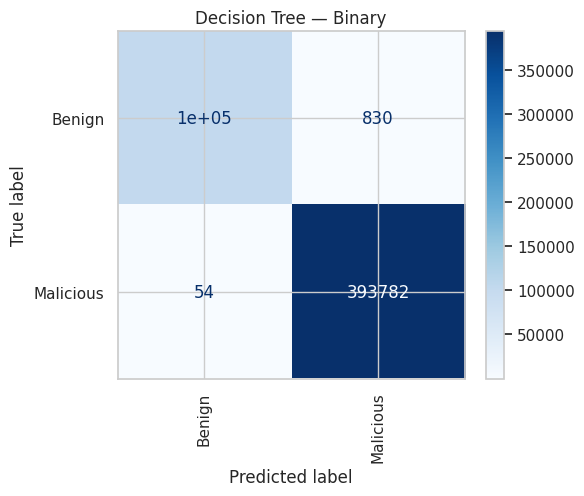

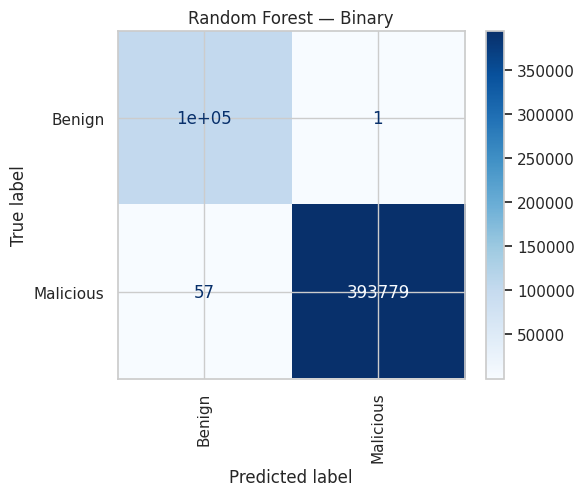

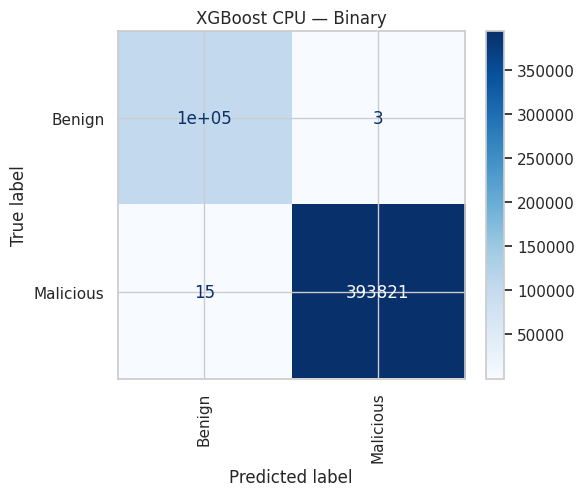

In [16]:
bin_labels = ["Benign", "Malicious"]

for name, res in [("Decision_Tree", res_dt_bin),
                  ("Random_Forest", res_rf_bin),
                  ("XGBoost_CPU",   res_xgb_bin)]:
    plot_confusion(
        y_te_b, res["y_pred"],
        class_names=bin_labels,
        title=f"{name.replace('_',' ')} — Binary"
    )

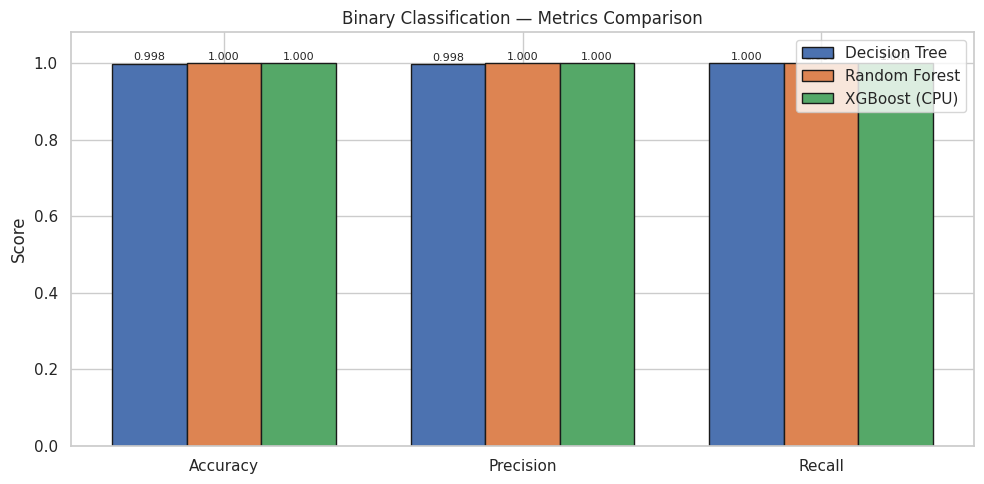

In [17]:
# Bar chart comparison
metrics = ["Accuracy", "Precision", "Recall"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for i, (algo, res) in enumerate([
    ("Decision Tree", res_dt_bin),
    ("Random Forest", res_rf_bin),
    ("XGBoost (CPU)", res_xgb_bin)
]):
    vals = [res["accuracy"], res["precision"], res["recall"]]
    bars = ax.bar(x + i * width, vals, width, label=algo, color=colors[i], edgecolor="k")
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.003,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Binary Classification — Metrics Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Multiclass Classification
**Goal:** predict the specific attack type (or benign)

### 7.1 Decision Tree

In [18]:
dt_multi = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

res_dt_multi = train_and_report(
    "Decision Tree", dt_multi,
    X_tr_m, y_tr_m, X_te_m, y_te_m,
    task="multiclass", class_names=le.classes_
)


  Decision Tree  [MULTICLASS]
  Training time : 62.70s
  Accuracy      : 0.9744
  Precision     : 0.9645  (weighted avg)
  Recall        : 0.9744  (weighted avg)

                precision    recall  f1-score   support

        benign       0.93      1.00      0.96    102699
  gafgyt.combo       0.77      0.97      0.86     12442
   gafgyt.junk       1.00      0.34      0.51      6258
   gafgyt.scan       0.00      0.00      0.00      6218
    gafgyt.tcp       1.00      0.94      0.97     19406
    gafgyt.udp       0.95      1.00      0.97     21533
     mirai.ack       1.00      1.00      1.00     56029
    mirai.scan       1.00      1.00      1.00     51231
     mirai.syn       1.00      1.00      1.00     63423
     mirai.udp       1.00      1.00      1.00    111195
mirai.udpplain       1.00      1.00      1.00     46102

      accuracy                           0.97    496536
     macro avg       0.88      0.84      0.84    496536
  weighted avg       0.96      0.97      0.97    4

### 7.2 Random Forest

In [21]:
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

res_rf_multi = train_and_report(
    "Random Forest", rf_multi,
    X_tr_m, y_tr_m, X_te_m, y_te_m,
    task="multiclass", class_names=le.classes_
)


  Random Forest  [MULTICLASS]
  Training time : 29.82s
  Accuracy      : 0.9904
  Precision     : 0.9918  (weighted avg)
  Recall        : 0.9904  (weighted avg)

                precision    recall  f1-score   support

        benign       1.00      1.00      1.00    102699
  gafgyt.combo       0.79      1.00      0.88     12442
   gafgyt.junk       0.98      0.47      0.63      6258
   gafgyt.scan       1.00      1.00      1.00      6218
    gafgyt.tcp       1.00      0.94      0.97     19406
    gafgyt.udp       0.95      1.00      0.97     21533
     mirai.ack       1.00      1.00      1.00     56029
    mirai.scan       1.00      1.00      1.00     51231
     mirai.syn       1.00      1.00      1.00     63423
     mirai.udp       1.00      1.00      1.00    111195
mirai.udpplain       1.00      1.00      1.00     46102

      accuracy                           0.99    496536
     macro avg       0.97      0.95      0.95    496536
  weighted avg       0.99      0.99      0.99    4

### 7.3 XGBoost (CPU only)

In [25]:
n_classes = len(le.classes_)

# xgb_multi = XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     # это магические параметры, которые делают обучение на порядки быстрее, не юзаем их)
#     # subsample=0.8,
#     # colsample_bytree=0.8,
#     # tree_method="hist",
    
#     # objective="multi:softmax",
#     num_class=n_classes,
#     device="cpu",
#     use_label_encoder=False,
#     # eval_metric="mlogloss",
#     # eval_metric="logloss",
#     random_state=RANDOM_STATE,
#     verbosity=0
# )
xgb_multi = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    # это магические параметры, которые делают обучение на порядки быстрее, не юзаем их)
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    # p.s. но без них она не вывозит мультикласс
    device="cpu",
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    verbosity=0
)

res_xgb_multi = train_and_report(
    "XGBoost (CPU)", xgb_multi,
    X_tr_m, y_tr_m, X_te_m, y_te_m,
    task="multiclass", class_names=le.classes_
)


  XGBoost (CPU)  [MULTICLASS]
  Training time : 33.77s
  Accuracy      : 0.9977
  Precision     : 0.9978  (weighted avg)
  Recall        : 0.9977  (weighted avg)

                precision    recall  f1-score   support

        benign       1.00      1.00      1.00    102699
  gafgyt.combo       1.00      1.00      1.00     12442
   gafgyt.junk       1.00      1.00      1.00      6258
   gafgyt.scan       1.00      1.00      1.00      6218
    gafgyt.tcp       1.00      0.94      0.97     19406
    gafgyt.udp       0.95      1.00      0.97     21533
     mirai.ack       1.00      1.00      1.00     56029
    mirai.scan       1.00      1.00      1.00     51231
     mirai.syn       1.00      1.00      1.00     63423
     mirai.udp       1.00      1.00      1.00    111195
mirai.udpplain       1.00      1.00      1.00     46102

      accuracy                           1.00    496536
     macro avg       1.00      0.99      0.99    496536
  weighted avg       1.00      1.00      1.00    4

### 7.4 Multiclass — Summary & Confusion Matrices

In [26]:
multi_summary = pd.DataFrame({
    "Algorithm":  ["Decision Tree", "Random Forest", "XGBoost (CPU)"],
    "Accuracy":   [res_dt_multi["accuracy"],  res_rf_multi["accuracy"],  res_xgb_multi["accuracy"]],
    "Precision (weighted)": [res_dt_multi["precision"], res_rf_multi["precision"], res_xgb_multi["precision"]],
    "Recall (weighted)":    [res_dt_multi["recall"],    res_rf_multi["recall"],    res_xgb_multi["recall"]],
    "Train time (s)": [res_dt_multi["train_time"], res_rf_multi["train_time"], res_xgb_multi["train_time"]],
})

print("\n── MULTICLASS CLASSIFICATION RESULTS ──────────────────")
print(multi_summary.to_string(index=False, float_format="{:.4f}".format))


── MULTICLASS CLASSIFICATION RESULTS ──────────────────
    Algorithm  Accuracy  Precision (weighted)  Recall (weighted)  Train time (s)
Decision Tree    0.9744                0.9645             0.9744         62.7050
Random Forest    0.9904                0.9918             0.9904         29.8167
XGBoost (CPU)    0.9977                0.9978             0.9977         33.7650


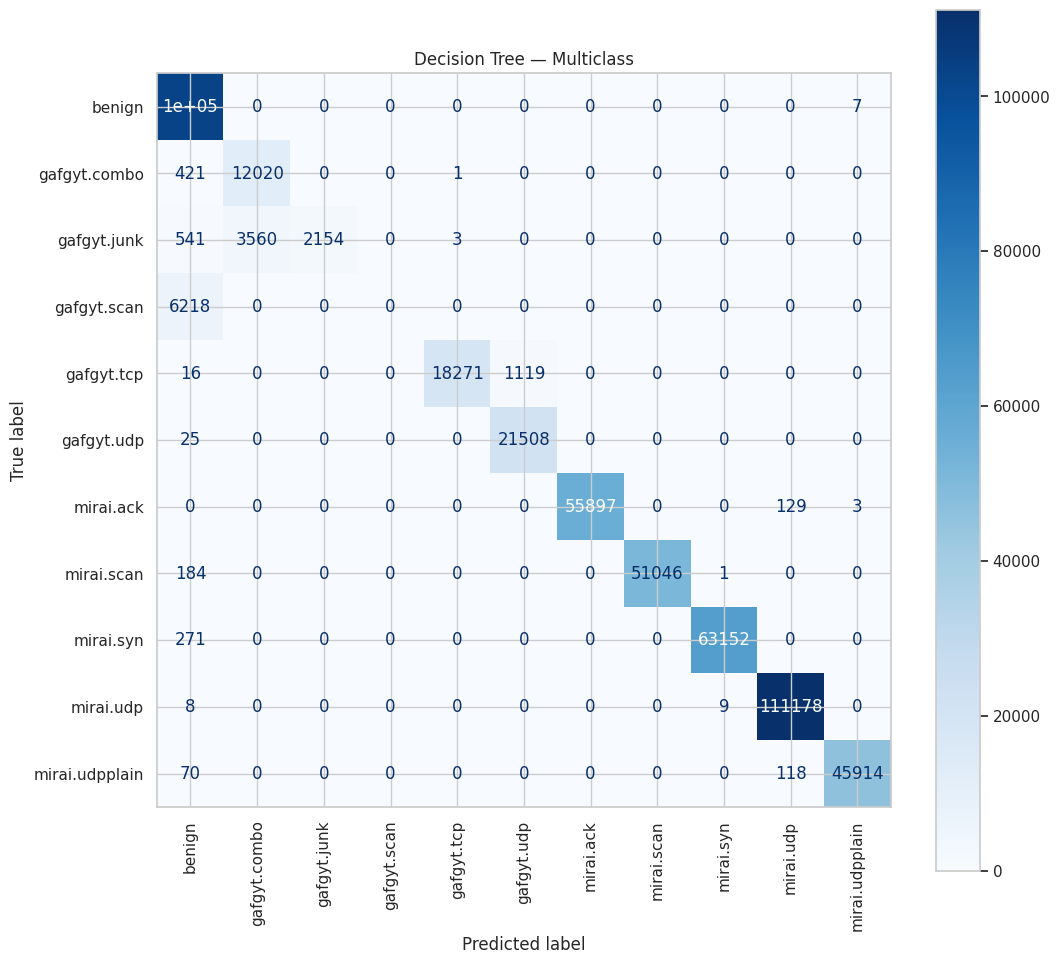

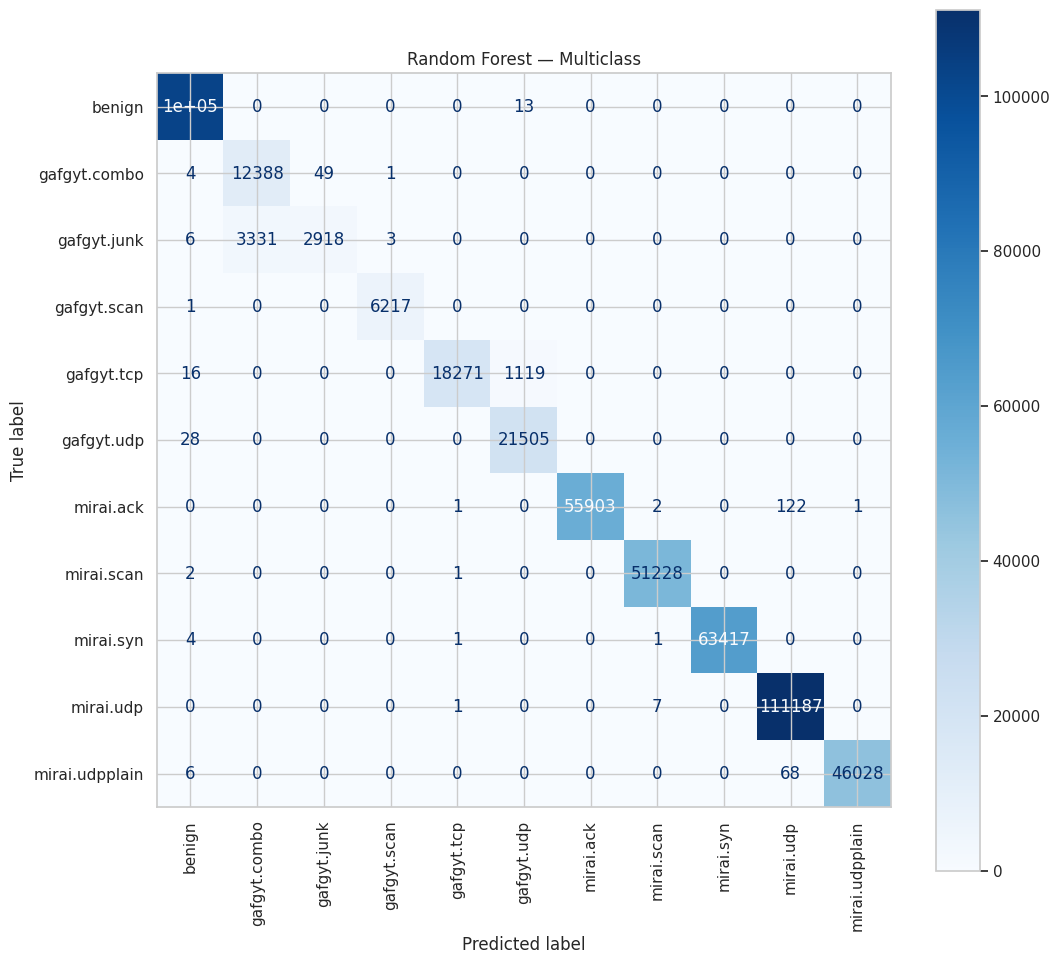

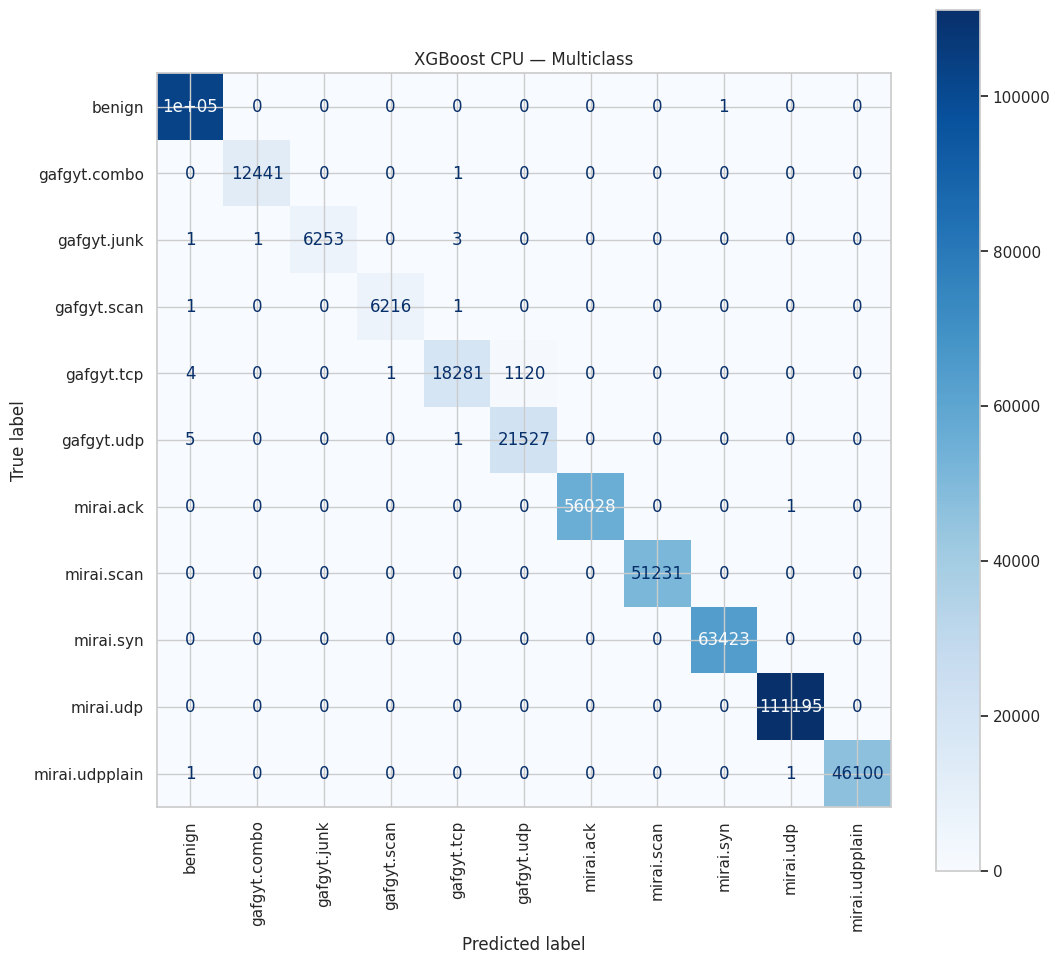

In [27]:
for name, res in [("Decision_Tree", res_dt_multi),
                  ("Random_Forest", res_rf_multi),
                  ("XGBoost_CPU",   res_xgb_multi)]:
    plot_confusion(
        y_te_m, res["y_pred"],
        class_names=le.classes_,
        title=f"{name.replace('_',' ')} — Multiclass"
    )

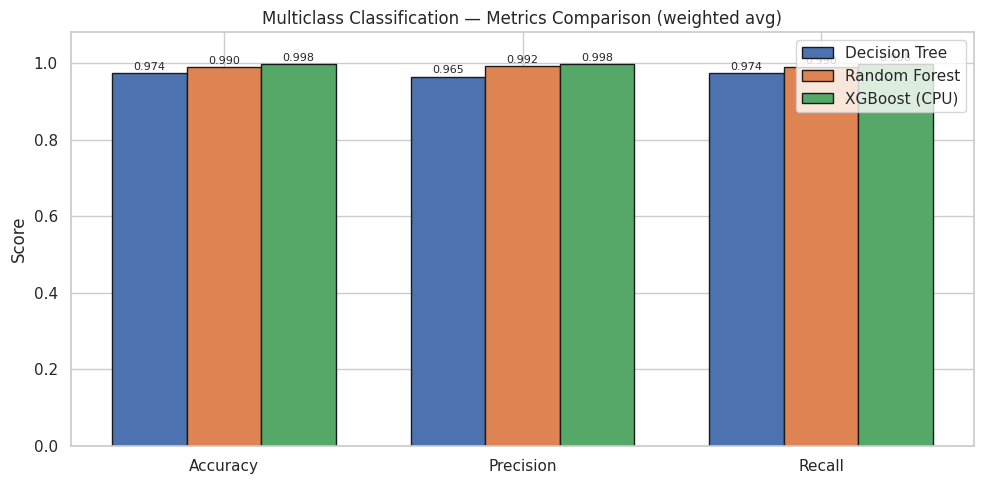

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, (algo, res) in enumerate([
    ("Decision Tree", res_dt_multi),
    ("Random Forest", res_rf_multi),
    ("XGBoost (CPU)", res_xgb_multi)
]):
    vals = [res["accuracy"], res["precision"], res["recall"]]
    bars = ax.bar(x + i * width, vals, width, label=algo, color=colors[i], edgecolor="k")
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.003,
                f"{b.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Multiclass Classification — Metrics Comparison (weighted avg)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Final Summary

In [31]:
print("\n" + "="*65)
print(" FINAL RESULTS SUMMARY")
print("="*65)

print("\n[BINARY CLASSIFICATION — Benign vs Malicious]")
print(bin_summary.to_string(index=False, float_format="{:.4f}".format))

print("\n[MULTICLASS CLASSIFICATION — Attack Type]")
print(multi_summary.to_string(index=False, float_format="{:.4f}".format))
print()

# Best model per task
best_bin   = bin_summary.loc[bin_summary["Accuracy"].idxmax(), "Algorithm"]
best_multi = multi_summary.loc[multi_summary["Accuracy"].idxmax(), "Algorithm"]
print(f"Best binary model    : {best_bin}")
print(f"Best multiclass model: {best_multi}")


 FINAL RESULTS SUMMARY

[BINARY CLASSIFICATION — Benign vs Malicious]
    Algorithm  Accuracy  Precision  Recall  Train time (s)
Decision Tree    0.9982     0.9979  0.9999         63.3313
Random Forest    0.9999     1.0000  0.9999         27.5016
XGBoost (CPU)    1.0000     1.0000  1.0000         96.9868

[MULTICLASS CLASSIFICATION — Attack Type]
    Algorithm  Accuracy  Precision (weighted)  Recall (weighted)  Train time (s)
Decision Tree    0.9744                0.9645             0.9744         62.7050
Random Forest    0.9904                0.9918             0.9904         29.8167
XGBoost (CPU)    0.9977                0.9978             0.9977         33.7650

Best binary model    : XGBoost (CPU)
Best multiclass model: XGBoost (CPU)
